In [1]:
import pandas as pd

In [2]:
df_trajectories = pd.read_csv('monthly_trajectories.csv')
definitive_df = pd.read_csv('definitive_df.csv')
print(df_trajectories)

      YearMonth            source              target  Rides planned  \
0       2019-01  's-Hertogenbosch     Arnhem Centraal             57   
1       2019-01  's-Hertogenbosch   Den Haag Centraal           1106   
2       2019-01  's-Hertogenbosch              Deurne            757   
3       2019-01  's-Hertogenbosch           Dordrecht            100   
4       2019-01  's-Hertogenbosch  Eindhoven Centraal            257   
...         ...               ...                 ...            ...   
39923   2024-12            Zwolle          Roosendaal           1118   
39924   2024-12            Zwolle  Rotterdam Centraal             13   
39925   2024-12            Zwolle    Schiphol Airport             24   
39926   2024-12            Zwolle    Utrecht Centraal           1163   
39927   2024-12            Zwolle             Zutphen             17   

       Final arrival delay  Final arrival cancelled  Completely cancelled  \
0                       20                        4       

In [3]:
traj_df = df_trajectories[df_trajectories['Significant Delay']].groupby(['source', 'target']).size().reset_index(name='Significant Delay Count')
traj_df = traj_df.sort_values(by='Significant Delay Count', ascending=False)
print(traj_df)

                  source                 target  Significant Delay Count
1235          Maastricht     Eindhoven Centraal                       72
1721    Utrecht Centraal       Schiphol Airport                       72
1528    Schiphol Airport    Amersfoort Centraal                       72
241   Amsterdam Centraal    Amersfoort Centraal                       70
588    Den Haag Centraal     Eindhoven Centraal                       70
...                  ...                    ...                      ...
1334                 Oss             Vlissingen                        1
1336         PON Leusden    Amersfoort Centraal                        1
508                Breda         Bergen op Zoom                        1
504                Breda  Amersfoort Schothorst                        1
971           Heerenveen     Rotterdam Centraal                        1

[1943 rows x 3 columns]


In [4]:
filtered_df = df_trajectories[(df_trajectories['source'] == 'Maastricht') & (df_trajectories['target'] == 'Eindhoven Centraal')]
print(filtered_df)

      YearMonth      source              target  Rides planned  \
255     2019-01  Maastricht  Eindhoven Centraal             62   
675     2019-02  Maastricht  Eindhoven Centraal             59   
1123    2019-03  Maastricht  Eindhoven Centraal             60   
1594    2019-04  Maastricht  Eindhoven Centraal             53   
2079    2019-05  Maastricht  Eindhoven Centraal            137   
...         ...         ...                 ...            ...   
37272   2024-08  Maastricht  Eindhoven Centraal             59   
37845   2024-09  Maastricht  Eindhoven Centraal             60   
38473   2024-10  Maastricht  Eindhoven Centraal             62   
39119   2024-11  Maastricht  Eindhoven Centraal             60   
39716   2024-12  Maastricht  Eindhoven Centraal             61   

       Final arrival delay  Final arrival cancelled  Completely cancelled  \
255                     30                        0                     0   
675                     24                        0  

In [5]:
traj_df[traj_df['Significant Delay Count'] >= 36]

,source,target,Significant Delay Count
1235,Maastricht,Eindhoven Centraal,72
1721,Utrecht Centraal,Schiphol Airport,72
1528,Schiphol Airport,Amersfoort Centraal,72
241,Amsterdam Centraal,Amersfoort Centraal,70
588,Den Haag Centraal,Eindhoven Centraal,70
...,...,...,...
650,Den Haag HS,Rotterdam Centraal,36
25,'s-Hertogenbosch,Roosendaal,36
74,Alkmaar,Rotterdam Centraal,36
235,Amsterdam Bijlmer ArenA,Utrecht Centraal,36


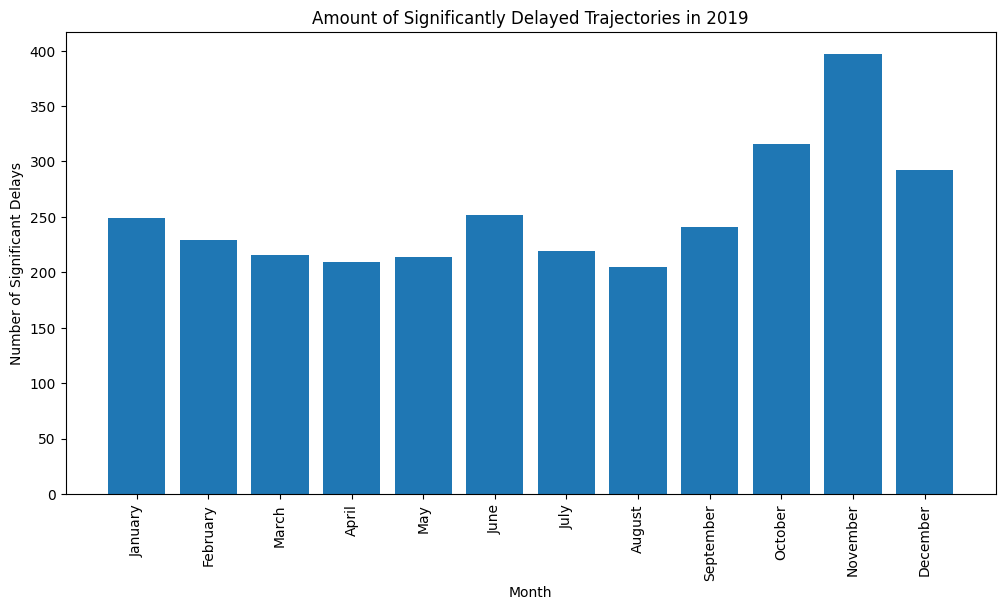

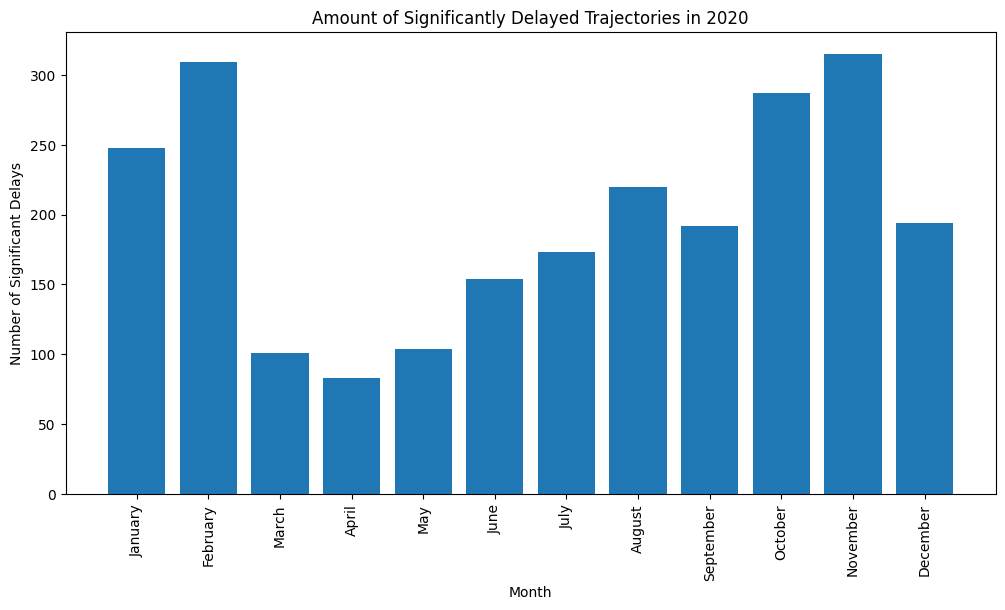

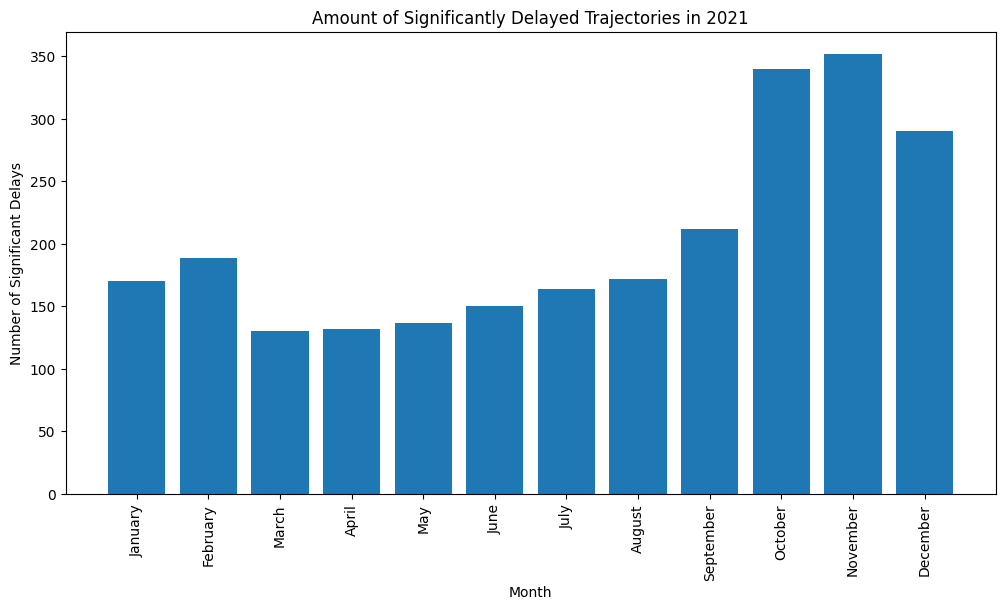

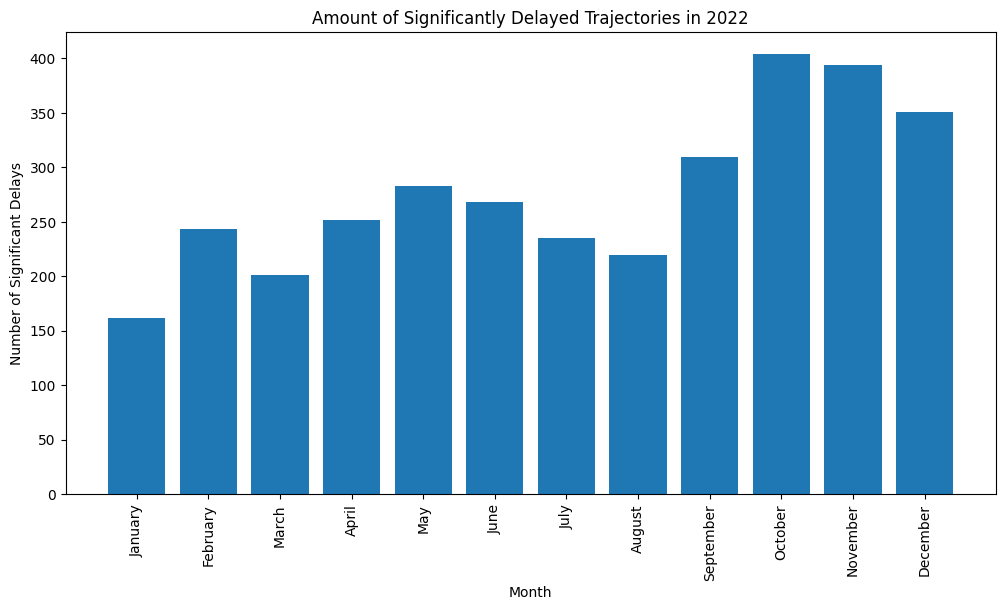

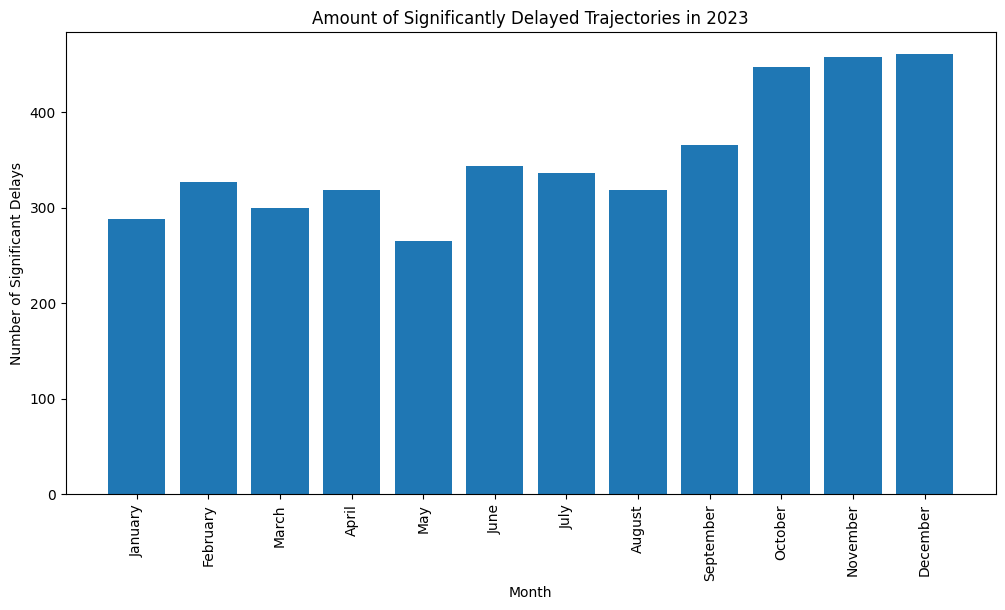

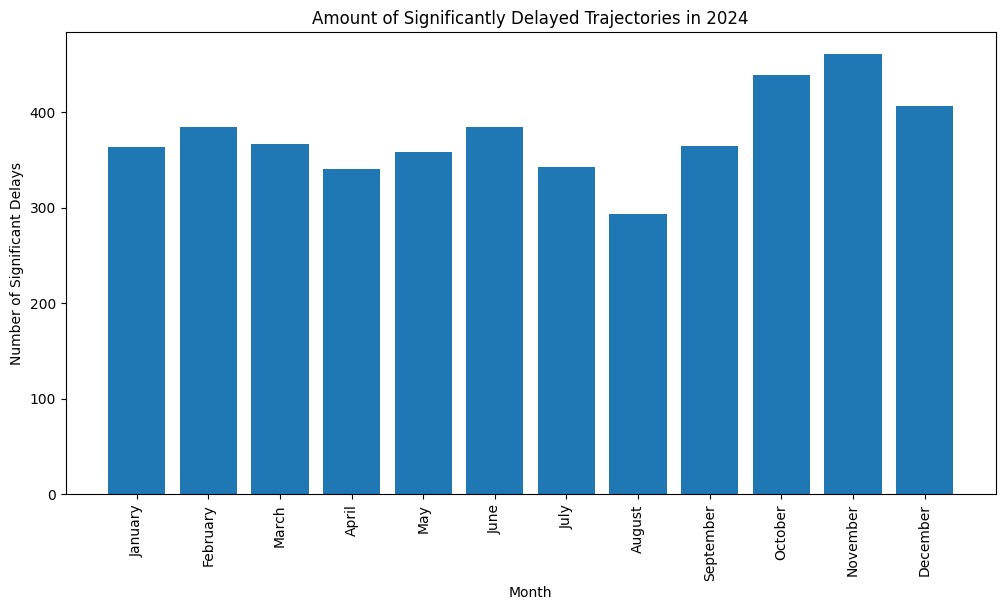

In [6]:
import calendar
import matplotlib.pyplot as plt

# Group by YearMonth and count the number of significant delays
monthly_delays = df_trajectories[df_trajectories['Significant Delay']].groupby('YearMonth').size()

# Extract year and month from YearMonth
monthly_delays.index = pd.to_datetime(monthly_delays.index)
monthly_delays = monthly_delays.reset_index()
monthly_delays['Year'] = monthly_delays['YearMonth'].dt.year
monthly_delays['Month'] = monthly_delays['YearMonth'].dt.month

# Plot the data for each year
unique_years = monthly_delays['Year'].unique()
for year in unique_years:
    yearly_data = monthly_delays[monthly_delays['Year'] == year]
    
    plt.figure(figsize=(12, 6))
    plt.bar(yearly_data['Month'], yearly_data[0])
    
    # Set the x-axis labels to the month names
    plt.xticks(ticks=yearly_data['Month'], labels=yearly_data['Month'].apply(lambda x: calendar.month_name[x]), rotation=90)
    plt.title(f'Amount of Significantly Delayed Trajectories in {year}')
    plt.xlabel('Month')
    plt.ylabel('Number of Significant Delays')
    plt.show()

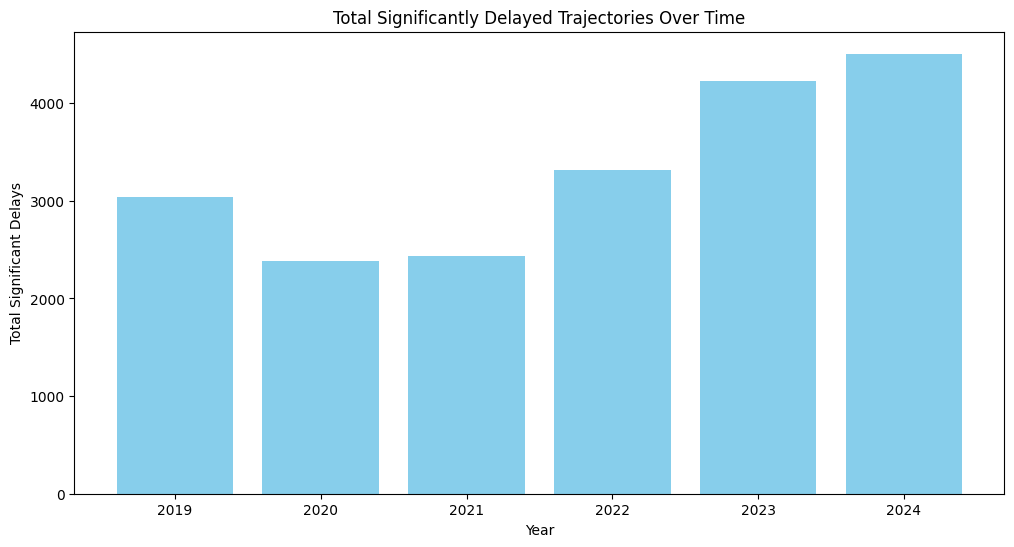

,Year,0
0,2019,3039
1,2020,2380
2,2021,2438
3,2022,3321
4,2023,4228
5,2024,4507


In [7]:
# Group by Year and sum the significant delays
yearly_significant_delays = monthly_delays.groupby('Year')[0].sum().reset_index()

# Plot the data
plt.figure(figsize=(12, 6))
plt.bar(yearly_significant_delays['Year'], yearly_significant_delays[0], color='skyblue')

plt.title('Total Significantly Delayed Trajectories Over Time')
plt.xlabel('Year')
plt.ylabel('Total Significant Delays')
plt.xticks(yearly_significant_delays['Year'])
plt.show()

yearly_significant_delays

In [8]:
print(definitive_df.head())

     RDT-ID                             Trajectory        Date  \
0  [738804]  Rotterdam Centraal - Utrecht Centraal  2019-01-01   
1  [738805]  Utrecht Centraal - Rotterdam Centraal  2019-01-01   
2  [738806]  Rotterdam Centraal - Utrecht Centraal  2019-01-01   
3  [738807]  Utrecht Centraal - Rotterdam Centraal  2019-01-01   
4  [738808]  Rotterdam Centraal - Utrecht Centraal  2019-01-01   

  Day of the Week  Maximum Delay  Arrival Delay of Last Stop (min)  \
0         Tuesday              1                               0.0   
1         Tuesday              2                               0.0   
2         Tuesday              2                               0.0   
3         Tuesday              2                               2.0   
4         Tuesday              1                               0.0   

   Nr. of Planned Stops Nr. of Cancelled Arrivals Nr. of Cancelled Departures  \
0                     5                         0                           0   
1                   

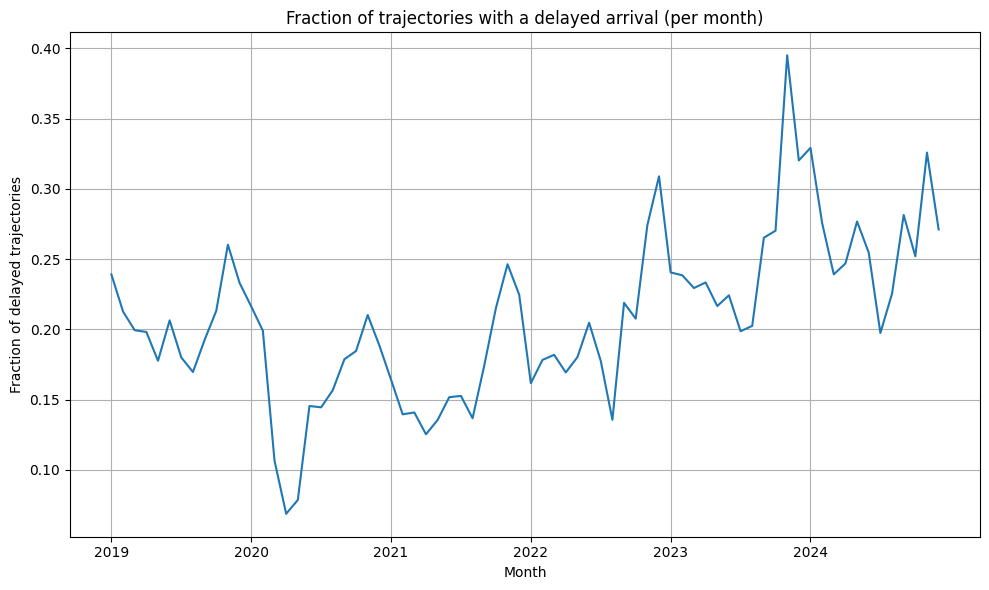

In [9]:
# Convert 'Date' column to datetime format
definitive_df['Date'] = pd.to_datetime(definitive_df['Date'])

# Extract year and month from the datetime column
definitive_df['Year'] = definitive_df['Date'].dt.year
definitive_df['Month'] = definitive_df['Date'].dt.month

# Filter the data for delayed edges (arrival delay of last stop > 0)
delayed_edges = definitive_df[definitive_df['Arrival Delay of Last Stop (min)'] > 0]

# Group the data by year and month, and count the number of trajectories with delayed edges for each month
delayed_counts = delayed_edges.groupby(['Year', 'Month']).size()

# Calculate the total number of trajectories for each month
total_counts = definitive_df.groupby(['Year', 'Month']).size()

# Calculate the percentage of delayed trajectories compared to the total trajectories for each month
percentage_delayed = (delayed_counts / total_counts)

# Reset index to convert MultiIndex to columns
percentage_delayed = percentage_delayed.reset_index()

# Plot the percentages for delayed trajectories
plt.figure(figsize=(10, 6))
plt.plot(range(len(percentage_delayed)), percentage_delayed[0], linestyle='-')
plt.xlabel('Month')
plt.ylabel('Fraction of delayed trajectories')
plt.title('Fraction of trajectories with a delayed arrival (per month)')

# Set x-axis ticks to display years
tick_positions = percentage_delayed.index[::12]    # Show ticks every 12 months (i.e., each year)
tick_labels = percentage_delayed['Year'].unique()  # Use unique years as tick labels
plt.xticks(tick_positions, tick_labels)

plt.grid(True)
plt.tight_layout()
plt.show()